# MNIST DNN on GPU

PyTorch で多層パーセプトロンを作り、GPU が使える環境では CUDA で学習します。
`torchvision` を使わず、MNIST の IDX ファイルを直接ダウンロードするので、このノートブック単体で動かしやすい構成です。


In [23]:
import gzip
import random
import struct
import urllib.request
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

seed = 42
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

DATA_DIR = Path('data/mnist')
DATA_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch: {torch.__version__}')
print(f'device: {device}')
if torch.cuda.is_available():
    print(f'gpu: {torch.cuda.get_device_name(0)}')
else:
    print('GPU は見えていないため CPU で実行します。')


torch: 2.5.1+cu121
device: cuda
gpu: Tesla T4


In [24]:
MNIST_URLS = {
    'train_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
    'train_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
    'test_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
    'test_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz',
}


def download(url: str, path: Path) -> None:
    if path.exists():
        print(f'cached: {path.name}')
        return
    print(f'downloading: {url}')
    urllib.request.urlretrieve(url, path)


def read_idx_images(path: Path) -> torch.Tensor:
    with gzip.open(path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        if magic != 2051:
            raise ValueError(f'unexpected image magic number: {magic}')
        data = torch.frombuffer(f.read(), dtype=torch.uint8).clone()
    return data.view(num_images, rows * cols).float() / 255.0


def read_idx_labels(path: Path) -> torch.Tensor:
    with gzip.open(path, 'rb') as f:
        magic, num_items = struct.unpack('>II', f.read(8))
        if magic != 2049:
            raise ValueError(f'unexpected label magic number: {magic}')
        labels = torch.frombuffer(f.read(), dtype=torch.uint8).clone()
    return labels.to(torch.long)


paths = {name: DATA_DIR / Path(url).name for name, url in MNIST_URLS.items()}
for name, url in MNIST_URLS.items():
    download(url, paths[name])

x_train = read_idx_images(paths['train_images'])
y_train = read_idx_labels(paths['train_labels'])
x_test = read_idx_images(paths['test_images'])
y_test = read_idx_labels(paths['test_labels'])

print('train:', x_train.shape, y_train.shape)
print('test :', x_test.shape, y_test.shape)


cached: train-images-idx3-ubyte.gz
cached: train-labels-idx1-ubyte.gz
cached: t10k-images-idx3-ubyte.gz
cached: t10k-labels-idx1-ubyte.gz
train: torch.Size([60000, 784]) torch.Size([60000])
test : torch.Size([10000, 784]) torch.Size([10000])


In [25]:
batch_size = 128
train_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    TensorDataset(x_test, y_test),
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


class MNISTDNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = MNISTDNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

model


MNISTDNN(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [26]:
def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * yb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)

    return total_loss / total, correct / total


def train_one_epoch(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


In [27]:
epochs = 100
history = []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
    })
    print(
        f"epoch {epoch:02d} "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4%} "
        f"test_loss={test_loss:.4f} test_acc={test_acc:.4%}"
    )


epoch 01 train_loss=0.2290 train_acc=93.0350% test_loss=0.1113 test_acc=96.6900%
epoch 02 train_loss=0.0905 train_acc=97.2733% test_loss=0.0795 test_acc=97.7000%
epoch 03 train_loss=0.0664 train_acc=97.9950% test_loss=0.0844 test_acc=97.6000%
epoch 04 train_loss=0.0507 train_acc=98.4417% test_loss=0.0719 test_acc=97.8800%
epoch 05 train_loss=0.0410 train_acc=98.7217% test_loss=0.0824 test_acc=97.6300%
epoch 06 train_loss=0.0351 train_acc=98.9150% test_loss=0.1004 test_acc=97.2000%
epoch 07 train_loss=0.0342 train_acc=98.9683% test_loss=0.0914 test_acc=97.8600%
epoch 08 train_loss=0.0277 train_acc=99.1367% test_loss=0.0919 test_acc=97.8800%
epoch 09 train_loss=0.0236 train_acc=99.2667% test_loss=0.0848 test_acc=98.0500%
epoch 10 train_loss=0.0216 train_acc=99.3767% test_loss=0.0876 test_acc=98.0200%
epoch 11 train_loss=0.0176 train_acc=99.4533% test_loss=0.0901 test_acc=97.8900%
epoch 12 train_loss=0.0191 train_acc=99.4433% test_loss=0.0895 test_acc=98.2300%
epoch 13 train_loss=0.0195 t

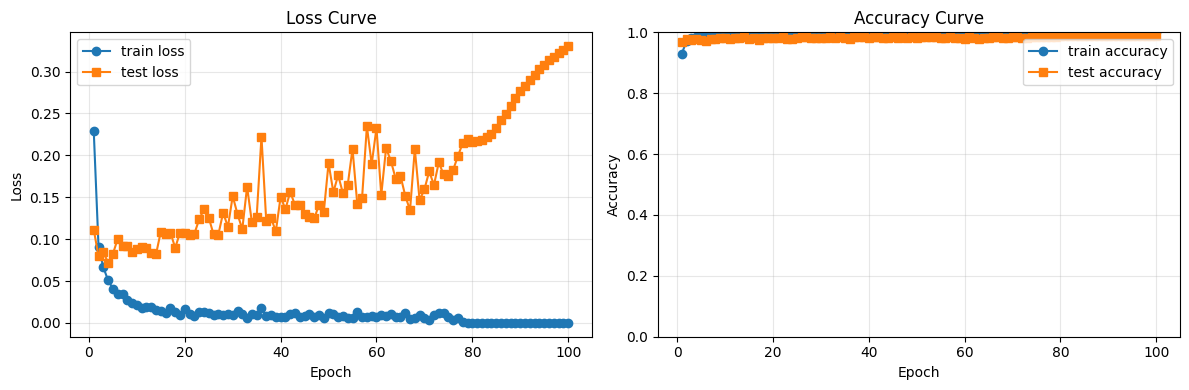

In [28]:
import matplotlib.pyplot as plt

epochs_axis = [row['epoch'] for row in history]
train_loss_curve = [row['train_loss'] for row in history]
test_loss_curve = [row['test_loss'] for row in history]
train_acc_curve = [row['train_acc'] for row in history]
test_acc_curve = [row['test_acc'] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_axis, train_loss_curve, marker='o', label='train loss')
axes[0].plot(epochs_axis, test_loss_curve, marker='s', label='test loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_axis, train_acc_curve, marker='o', label='train accuracy')
axes[1].plot(epochs_axis, test_acc_curve, marker='s', label='test accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [29]:
final_train_loss, final_train_acc = evaluate(model, train_loader)
final_test_loss, final_test_acc = evaluate(model, test_loader)
print(f'final train loss: {final_train_loss:.6f}')
print(f'final train accuracy: {final_train_acc:.4%}')
print(f'final test loss: {final_test_loss:.6f}')
print(f'final test accuracy: {final_test_acc:.4%}')

# 先頭 10 件だけ予測を確認
sample_logits = model(x_test[:10].to(device))
sample_pred = sample_logits.argmax(dim=1).cpu()
print('pred :', sample_pred.tolist())
print('label:', y_test[:10].tolist())


final train loss: 0.000000
final train accuracy: 100.0000%
final test loss: 0.330362
final test accuracy: 98.7400%
pred : [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]
label: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]
